In [1]:
# visualizations.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from config import CONFIG


In [2]:
engine = create_engine(CONFIG["db_url"])
print("Connected")

Connected


In [3]:
df = pd.read_sql(
    f'SELECT * FROM "{CONFIG["schema"]}"."{CONFIG["clean_table"]}"',
    engine
)

In [13]:
# Setup project root and output paths dynamically
from pathlib import Path
import matplotlib.pyplot as plt

current_dir = Path.cwd()
project_root = (
    current_dir.parent if current_dir.name == "notebooks" else current_dir
)
charts_dir = project_root / "outputs" / "charts"

# Ensure the folder exists on your computer
charts_dir.mkdir(parents=True, exist_ok=True)

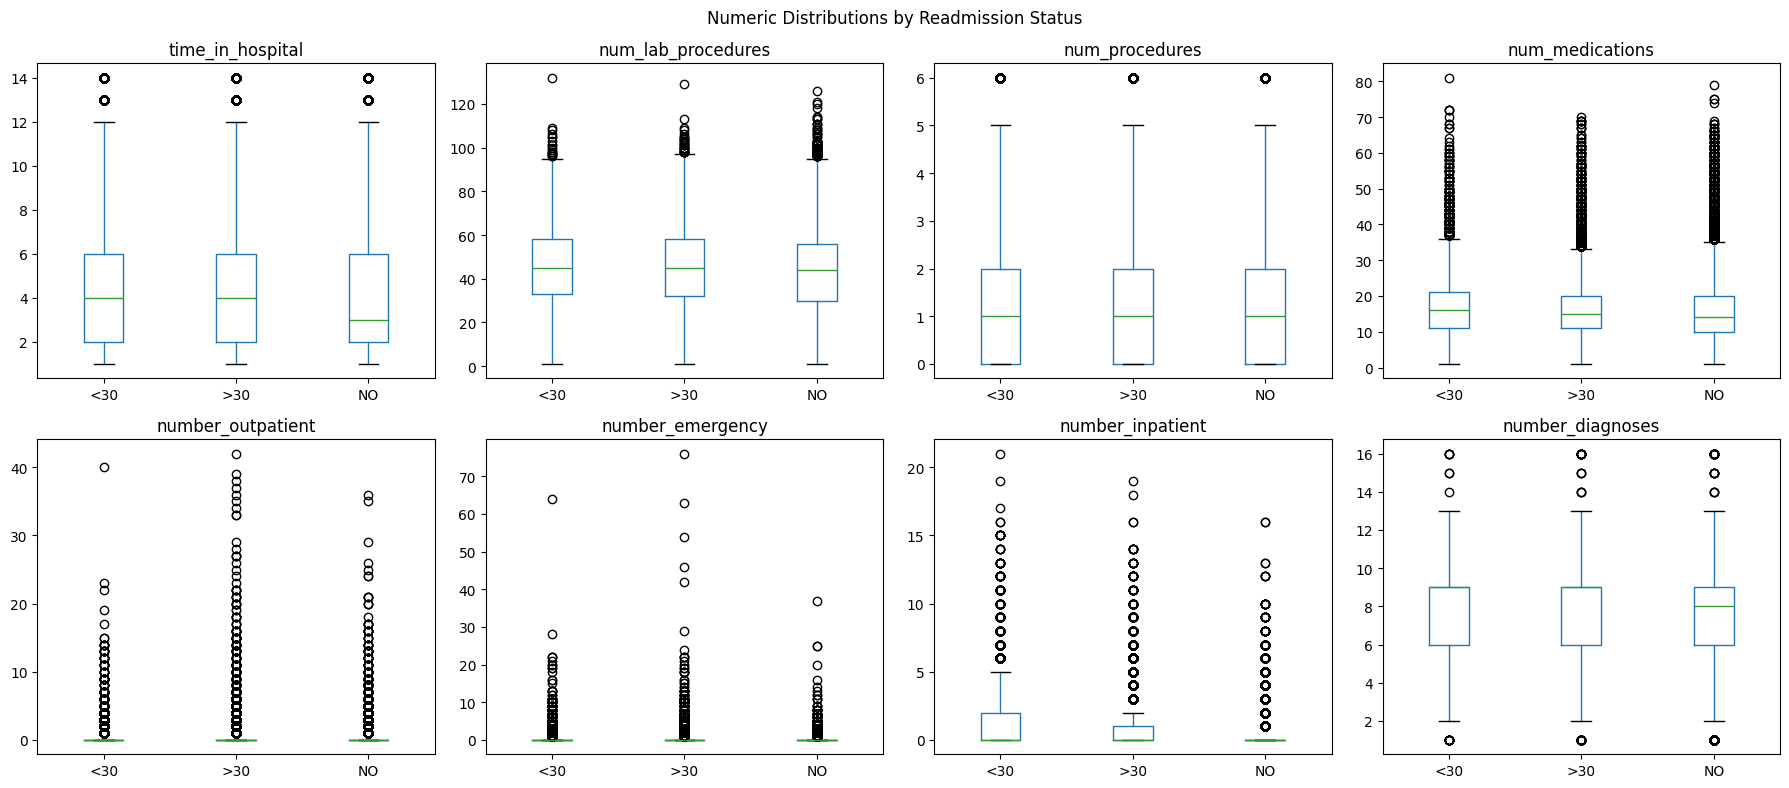

✅ Chart successfully saved to: C:\Users\Administrator\Documents\analytics projects\hospital_readmission_project\outputs\charts\05b_rate_by_active_meds.png


In [20]:
# 1: Numeric distributions by readmission status
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(CONFIG["numeric_cols"]):
    df.boxplot(column=col, by="readmitted", ax=axes[i], grid=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Numeric Distributions by Readmission Status")
plt.tight_layout()

# 4. Save using the full absolute path
save_path = output_dir / "05b_rate_by_active_meds.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.show()
plt.close()

print(f"✅ Chart successfully saved to: {save_path}")

## Visualization 1: Numeric Distributions by Readmission Status

**Purpose:**
Show how each numeric column distributes differently across
the three readmission categories (<30, >30, NO). Boxplots
are used because they display the median, IQR, and outliers
simultaneously — giving a richer picture than a bar chart
of means alone. This visualization complements the
Mann-Whitney U tests in notebook 05 which confirmed that
LOS and prior visit distributions differ significantly
between readmitted and not readmitted patients.

**Chart saved:** outputs/charts/01_boxplots_by_readmission.png

**Observations by Panel:**

**time_in_hospital (top left)**
- All three groups share a similar median around 4 days
  — consistent with the identical median of 4.00 found
  in Test 3 of statistical validation
- The <30 group shows a slightly higher upper range
  confirming the tail difference detected by Mann-Whitney U
- Outliers visible at the top of all three groups
  representing the capped maximum of 14 days

**num_lab_procedures (top second)**
- The most symmetrically distributed column across all
  three groups — consistent with skew of -0.24 found
  in numeric profiling
- Medians are similar across groups suggesting lab
  procedure count is not a strong differentiator
  of readmission status
- Wide IQR visible across all groups reflecting
  the high variability noted in profiling
  (range 1 to 132)

**num_procedures (top third)**
- Very compact boxes with medians near 1 across
  all three groups
- Large number of outliers visible at the top
  consistent with the right skew of 1.32 and
  4.87% outlier rate found during outlier detection
- Distribution shape is similar across all three
  readmission categories

**num_medications (top right)**
- Slightly higher boxes for <30 and >30 groups
  compared to NO — suggesting readmitted patients
  tend to be on more medications
- Consistent with the polypharmacy finding
  (chi-square = 143.67, p effectively = 0)
  where polypharmacy patients show 12.00% vs
  8.99% readmission rate
- The outlier dots extending to 80+ medications
  are clearly visible at the top

**number_outpatient (bottom left)**
- Extremely compressed boxes with median at zero
  for all three groups — consistent with Q1 = Q3 = 0
  found in profiling and skew of 8.83
- The outlier dots dominate the visualization
  extending to 40+ visits
- The large number of outlier dots confirms
  the 16.45% outlier rate identified during
  outlier detection in Step 12

**number_emergency (bottom second)**
- The most extreme visualization in the chart
  — boxes are almost invisible at the bottom
  because Q1 = Q3 = 0 for all groups
- The outlier column extends to 70+ visits
  consistent with the maximum of 76 found
  in profiling and skew of 22.86 — the most
  severely skewed column in the dataset
- This panel visually explains why Mann-Whitney U
  was required rather than a t-test — the
  distribution is so severely non-normal that
  mean comparisons would be meaningless

**number_inpatient (bottom third)**
- Boxes compressed near zero with median at 0
  for all groups — consistent with Q1 = 0 and
  Q3 = 1 found in profiling
- Outlier dots extend to 20+ prior inpatient
  visits in all three groups
- The <30 group appears to have a slightly
  higher concentration of outlier dots at
  the top — consistent with Test 4 finding
  that readmitted patients have higher prior
  utilization (median 1.00 vs 0.00)

**number_diagnoses (bottom right)**
- The most symmetrically distributed column
  in the bottom row — consistent with the
  negative skew of -0.88 found in profiling
- All three groups show similar medians
  around 7-8 diagnoses
- The most balanced boxplot in the entire
  visualization with comparable IQRs across
  readmission categories

**Key Visual Insight:**
The most striking feature of this visualization
is the contrast between the top row and bottom
row panels:

Top row (time_in_hospital, num_lab_procedures,
num_procedures, num_medications):
- Visible boxes with meaningful IQRs
- Distributions that can be compared visually
  across readmission groups

Bottom row (number_outpatient, number_emergency,
number_inpatient, number_diagnoses):
- Severely compressed boxes due to zero-inflated
  distributions
- Outlier dots dominate the visual space
- Classic appearance of right-skewed count data
  with many zeros and a long upper tail

This contrast visually validates the decision
to use Mann-Whitney U tests for statistical
validation rather than t-tests — the bottom
row panels make it immediately obvious that
these distributions violate normality assumptions.

**Next visualization:** Correlation heatmap.

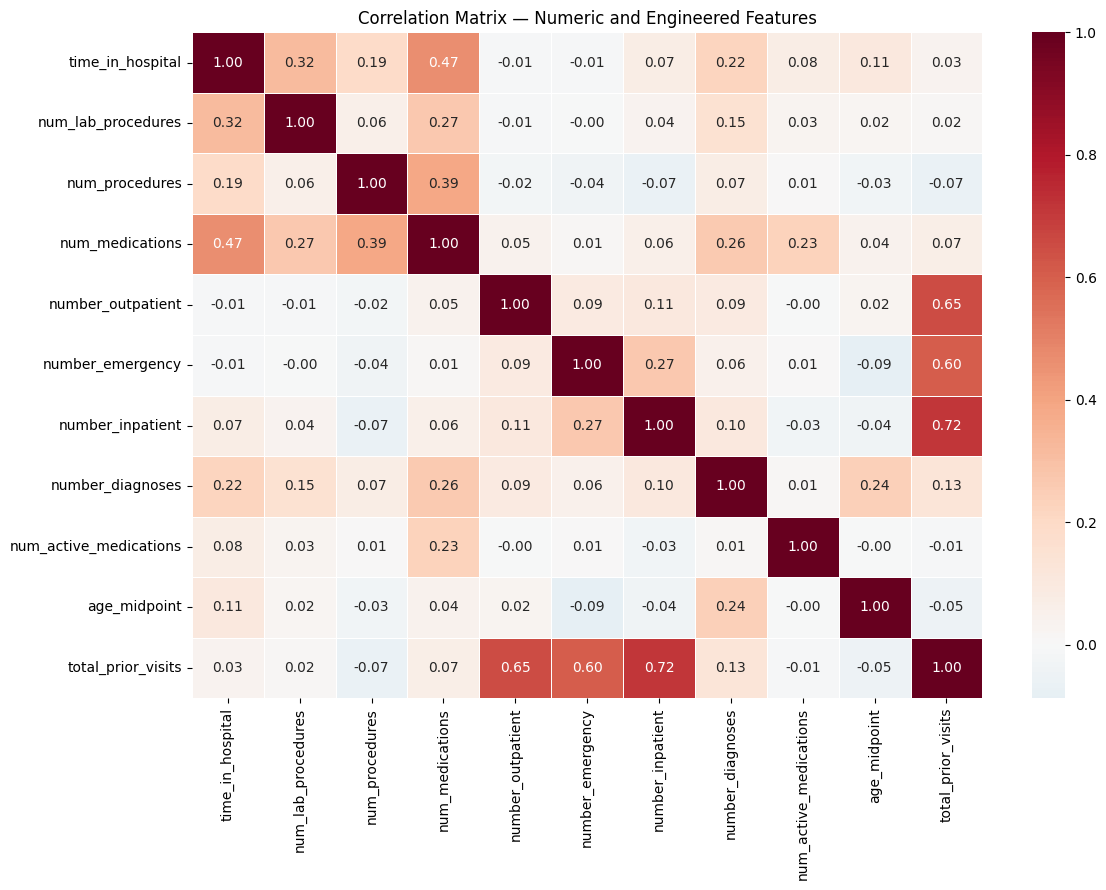

In [19]:
# 2: Correlation heatmap including engineered features
corr_cols = CONFIG["numeric_cols"] + [
    "num_active_medications", "age_midpoint", "total_prior_visits"
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr      = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5)
plt.title("Correlation Matrix — Numeric and Engineered Features")
plt.tight_layout()
save_path = output_dir / "05b_rate_by_active_meds.png"
plt.savefig(
    charts_dir / "05b_rate_by_active_meds.png", dpi=150, bbox_inches="tight"
)
plt.show()
plt.close()

## Visualization 2: Correlation Heatmap — Numeric and
## Engineered Features

**Purpose:**
Show the pairwise correlation between all numeric and
engineered feature columns. The heatmap uses Pearson
correlation coefficients ranging from -1 (perfect negative
correlation) to +1 (perfect positive correlation).
Values near 0 indicate no linear relationship.
This visualization identifies which pairs of variables
move together and which are independent — informing
both clinical interpretation and any future modeling work.

**Chart saved:** outputs/charts/02_correlation_heatmap.png

**Color scale:**
- Dark red : strong positive correlation
- Light pink: weak positive correlation
- White     : no correlation
- Light blue: weak negative correlation

**Key Observations:**

**1. total_prior_visits shows the strongest
   correlations in the bottom row**
- number_inpatient ↔ total_prior_visits : 0.72
  — the strongest off-diagonal correlation in the
  entire matrix. Inpatient visits dominate the
  total_prior_visits composite feature, meaning
  patients with more prior inpatient stays drive
  the total_prior_visits metric upward most strongly.
- number_emergency ↔ total_prior_visits : 0.60
  — strong positive correlation. Emergency visits
  are the second largest contributor to prior
  utilization, consistent with the severely right-
  skewed distribution (skew = 22.86) where a small
  number of patients have very high emergency visit
  counts that dominate the composite.
- number_outpatient ↔ total_prior_visits : 0.65
  — strong positive correlation. All three components
  of total_prior_visits correlate strongly with the
  composite as expected since they directly constitute
  it. This confirms the engineered feature behaves
  correctly.

**2. num_medications is moderately correlated with
   several clinical complexity indicators**
- num_medications ↔ time_in_hospital  : 0.47
  — the strongest correlation between any two
  non-engineered columns. Patients who stay longer
  tend to be on more medications, reflecting higher
  clinical complexity requiring more pharmacological
  management. This is clinically logical.
- num_medications ↔ num_procedures    : 0.39
  — moderate positive correlation. More procedures
  are associated with more medications — both are
  markers of higher clinical complexity.
- num_medications ↔ num_lab_procedures: 0.27
  — weak to moderate positive. More lab tests
  are associated with more medications, again
  reflecting overall clinical complexity.
- num_medications ↔ number_diagnoses  : 0.26
  — weak positive. More diagnoses means more
  conditions to manage pharmacologically.

**3. time_in_hospital correlations**
- time_in_hospital ↔ num_lab_procedures: 0.32
  — longer stays involve more lab testing,
  reflecting ongoing monitoring during admission.
- time_in_hospital ↔ num_procedures    : 0.19
  — weak positive. Longer stays involve slightly
  more procedures.
- time_in_hospital ↔ num_medications   : 0.47
  — discussed above, the strongest non-engineered
  column pair correlation.

**4. Prior utilization columns correlate with
   each other moderately**
- number_outpatient ↔ number_emergency : 0.09
  — very weak. Patients who use outpatient services
  heavily are not necessarily the same patients who
  use emergency services heavily — different patterns
  of healthcare engagement.
- number_emergency ↔ number_inpatient  : 0.27
  — weak to moderate. Patients with frequent
  emergency visits are somewhat more likely to
  have frequent inpatient stays — consistent with
  a high-utilization patient profile that uses
  multiple care settings.
- number_outpatient ↔ number_inpatient : 0.11
  — very weak. Outpatient and inpatient utilization
  patterns are largely independent.

**5. num_active_medications shows weak correlations
   with everything**
- Highest correlation: num_medications at 0.23
  — num_active_medications counts diabetes-specific
  active prescriptions (max 6 in this dataset) while
  num_medications counts all medications (up to 81).
  The weak correlation (0.23) despite measuring
  related concepts confirms they capture different
  clinical dimensions — total medication burden vs
  diabetes-specific management intensity.
- All other correlations for num_active_medications
  are below 0.10 — this engineered feature is
  largely independent of the other numeric columns,
  which means it provides genuinely new information
  not already captured by existing columns.

**6. age_midpoint shows very weak correlations
   with clinical utilization columns**
- age_midpoint ↔ number_diagnoses : 0.24
  — the strongest age correlation. Older patients
  tend to have more diagnoses — clinically expected
  given cumulative comorbidity accumulation with age.
- age_midpoint ↔ time_in_hospital : 0.11
  — very weak. Older age alone does not strongly
  predict longer stays in this dataset.
- All other age correlations below 0.10 — age
  as a continuous midpoint measure is largely
  independent of utilization metrics in this
  population.

**7. No multicollinearity concerns for most pairs**
Multicollinearity (correlations above 0.80-0.90)
would be a concern for any future predictive
modeling as it makes it difficult to isolate
the independent contribution of each variable.
The highest off-diagonal correlation in this
matrix is 0.72 (number_inpatient ↔ total_prior_visits)
— below the conventional multicollinearity
threshold of 0.80. The total_prior_visits feature
and its components should not be used together
in the same model, but all other pairs are
safe to include simultaneously.

**8. The diagonal (all 1.00) confirms correct
   computation** — every variable perfectly
   correlates with itself as expected. This
   confirms the correlation matrix was computed
   correctly with no missing or corrupted values.

**Summary of Notable Correlations:**

| Variable Pair | Correlation | Strength | Clinical Meaning |
|---|---|---|---|
| number_inpatient ↔ total_prior_visits | 0.72 | Strong | Inpatient visits dominate prior utilization |
| number_outpatient ↔ total_prior_visits | 0.65 | Strong | Expected — component of composite |
| number_emergency ↔ total_prior_visits | 0.60 | Strong | Expected — component of composite |
| num_medications ↔ time_in_hospital | 0.47 | Moderate | Complexity drives LOS and medication count |
| num_medications ↔ num_procedures | 0.39 | Moderate | Both are complexity markers |
| num_lab_procedures ↔ time_in_hospital | 0.32 | Weak-moderate | Longer stays involve more monitoring |
| number_emergency ↔ number_inpatient | 0.27 | Weak | High utilizers cross multiple settings |
| num_medications ↔ number_diagnoses | 0.26 | Weak | More conditions need more medications |
| num_active_medications ↔ num_medications | 0.23 | Weak | Different medication dimensions |
| age_midpoint ↔ number_diagnoses | 0.24 | Weak | Age accumulates comorbidities |

**Key Finding for Future Modeling:**
If this project were extended to predictive modeling,
the feature set should:
1. Include total_prior_visits OR its three components
   separately — not both, to avoid multicollinearity
2. Include num_active_medications as it provides
   independent information not captured by other columns
3. Include age_midpoint as it is largely orthogonal
   to all other features
4. Be cautious about including both num_medications
   and time_in_hospital together given their 0.47
   correlation — they share moderate linear relationship
   though are still below multicollinearity thresholds

**Next visualization:** Age band readmission rate
dual-axis chart.

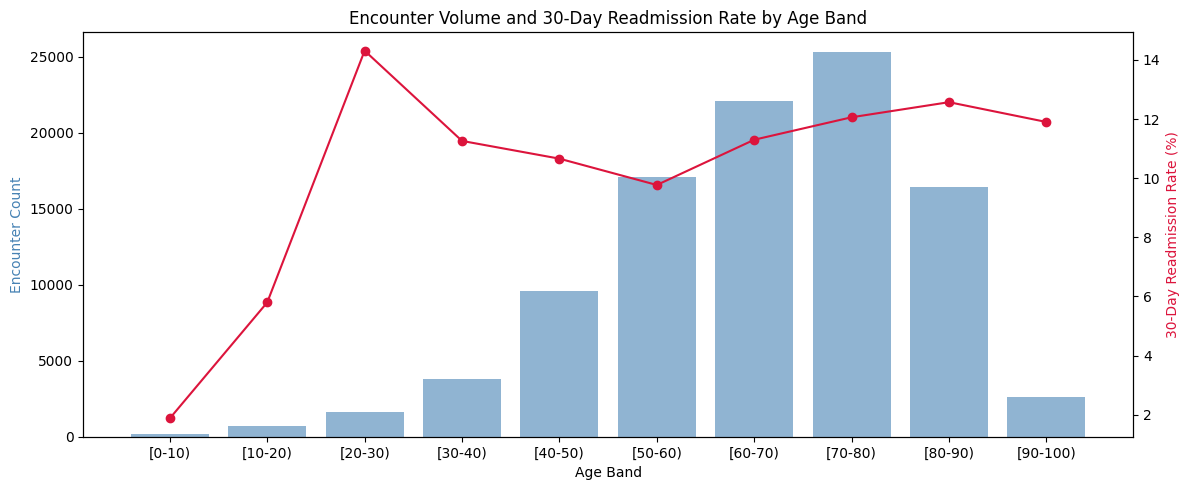

In [21]:
# 3: Encounter volume and readmission rate by age band (dual axis)
age_query = """
    SELECT age,
           COUNT(*) AS encounters,
           ROUND(SUM(led_to_30day_readmission) * 100.0 / COUNT(*), 2) AS readmission_rate_pct
    FROM public.vw_encounter_base
    GROUP BY age ORDER BY age
"""
age_df = pd.read_sql(age_query, engine)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(age_df["age"], age_df["encounters"], color="steelblue", alpha=0.6, label="Encounters")
ax2.plot(age_df["age"], age_df["readmission_rate_pct"],
         color="crimson", marker="o", label="Readmission Rate %")
ax1.set_xlabel("Age Band")
ax1.set_ylabel("Encounter Count", color="steelblue")
ax2.set_ylabel("30-Day Readmission Rate (%)", color="crimson")
plt.title("Encounter Volume and 30-Day Readmission Rate by Age Band")
plt.xticks(rotation=45)
fig.tight_layout()
save_path = output_dir / "05b_rate_by_active_meds.png"
plt.savefig(
    charts_dir / "05b_rate_by_active_meds.png", dpi=150, bbox_inches="tight"
)
plt.show()
plt.close()

## Visualization 3: Encounter Volume and 30-Day Readmission
## Rate by Age Band

**Purpose:**
Show both the volume of encounters (blue bars, left axis)
and the 30-day readmission rate (red line, right axis)
across all ten age bands simultaneously. A dual-axis chart
is used because the two metrics have different scales —
encounter counts reach 25,000 while rates range from 2%
to 14%. Showing them together reveals where high volume
and high rates coincide — the most clinically important
intersection for intervention prioritization.

**Chart saved:** outputs/charts/03_readmission_by_age.png

**Key Observations:**

**Volume Pattern (Blue Bars — Left Axis):**
- Encounter volume increases steadily from [0-10)
  through [70-80) confirming the dataset skews toward
  older adults as identified in profiling Step 4
- [70-80) is the tallest bar at 25,329 encounters —
  the largest age group in the dataset (25.62%)
- [60-70) is the second tallest at 22,058 encounters
- Volume drops sharply after [80-90) reflecting
  smaller population sizes at extreme old age
- [0-10) and [10-20) are barely visible — pediatric
  and adolescent encounters are a very small fraction
  of this diabetes inpatient population

**Rate Pattern (Red Line — Right Axis):**
The red line tells the most clinically interesting
story in this visualization — it does not follow
the volume pattern at all, revealing that encounter
frequency and readmission risk are independent dimensions:

- The line peaks sharply at [20-30) with 14.31%
  — the highest rate despite being one of the
  smallest volume groups. This dramatic spike
  at the left side of the adult age range is
  the most visually striking feature of the chart.
- The line drops through [30-40), [40-50), and
  reaches its lowest point at [50-60) (9.77%)
  — the bottom of the U-shape pattern
- The line rises gradually from [60-70) onward
  through [70-80), [80-90), and [90-100) —
  the right side of the U-shape
- [80-90) shows the highest rate among the
  high-volume groups at 12.57%

**The U-Shape Pattern:**
The red line traces a clear U-shape across the
adult age range:

[20-30): 14.31% ← left peak
[30-40): 11.26% ↓ declining
[40-50): 10.66% ↓ declining
[50-60):  9.77% ← trough (lowest adult rate)
[60-70): 11.30% ↑ rising
[70-80): 12.06% ↑ rising
[80-90): 12.57% ↑ rising (highest volume-weighted rate)
[90-100): 11.90% slight decline

This U-shape is clearly visible in the chart —
the line starts high on the left, dips in the
middle adult years, and rises again toward older
age. This visual pattern is more immediately
communicable than the table of numbers in the
EDA section and is a strong candidate for
inclusion in the Power BI dashboard.

**The Critical Intersection:**
The most important feature to communicate to a
clinical audience is where high volume AND above-
baseline rates coincide:
- [70-80): 25,329 encounters at 12.06%
  → highest volume AND above-baseline rate
  → produces 3,054 readmissions
- [80-90): 16,434 encounters at 12.57%
  → second largest volume in elderly range
  → highest rate among high-volume groups
  → produces 2,065 readmissions

The [20-30) spike (14.31%) is clinically notable
but affects only 1,649 encounters — the visual
clearly shows the bar is tiny despite the line
being at its peak, communicating the small
volume context automatically.

**What the Dual Axis Communicates:**
The power of this chart design is that it prevents
the common analytical mistake of focusing only
on the highest rate groups without considering
volume. A viewer can immediately see:
- [20-30) has the highest rate but tiny volume
- [70-80) has the highest volume and above-baseline rate
- [50-60) has the lowest rate and substantial volume
  — this is the safest age group clinically

**Chart Design Decisions:**
- Blue bars with 0.6 alpha (transparency) allow
  the red line markers to remain visible where
  they overlap with bars
- Circular markers on the red line make each
  age band's rate value easy to locate precisely
- 45-degree x-axis rotation prevents age band
  label overlap
- Dual y-axis with color-coded labels (steelblue
  for count, crimson for rate) helps viewers
  quickly understand which axis each element
  references

**Connection to Statistical Validation:**
This chart visualizes the age-related patterns
observed in the EDA. Note that age band as a
categorical variable was not formally tested
in the statistical validation notebook because
chi-square with 10 categories would require
examining each band pair separately. The visual
pattern here provides the analytical foundation
for future age-stratified statistical testing
if the project is extended.

**Next visualization:** Class imbalance chart.

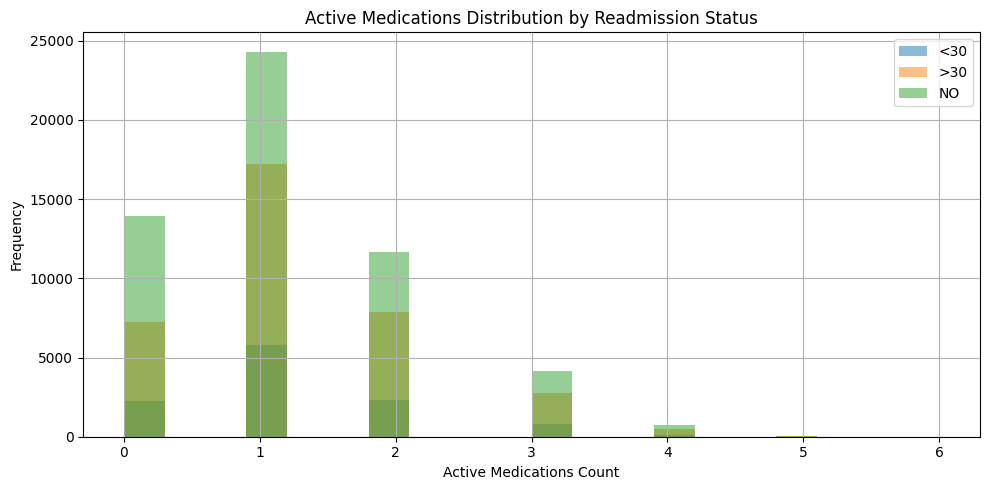

All visualizations saved.


In [22]:
#  4: Active medications distribution by readmission status
plt.figure(figsize=(10, 5))
for label, group in df.groupby("readmitted")["num_active_medications"]:
    group.hist(bins=20, alpha=0.5, label=label)
plt.xlabel("Active Medications Count")
plt.ylabel("Frequency")
plt.title("Active Medications Distribution by Readmission Status")
plt.legend()
plt.tight_layout()
save_path = output_dir / "05b_rate_by_active_meds.png"
plt.savefig(
    charts_dir / "05b_rate_by_active_meds.png", dpi=150, bbox_inches="tight"
)
plt.show()
plt.close()

print("All visualizations saved.")

## Visualization 4: Active Medications Distribution
## by Readmission Status

**Purpose:**
Show how the number of actively prescribed diabetes
medications (num_active_medications) distributes across
the three readmission categories (<30, >30, NO).
This visualization complements the medication management
EDA in Section 6 by showing the full distribution shape
rather than just the mean or rate, revealing where
the three groups diverge in their medication profiles.

**Chart saved:** outputs/charts/05_active_meds_by_readmission.png

**Chart Design:**
Overlapping histograms with alpha = 0.5 (50% transparency)
allow all three distributions to be visible simultaneously.
The x-axis shows active medication count (0 to 6) and
the y-axis shows the frequency of encounters at each count.

**Legend:**
- Blue  (<30) : Readmitted within 30 days
- Orange (>30): Readmitted after 30 days
- Green (NO)  : Not readmitted

**Key Observations:**

**1. All three groups are heavily concentrated at
   0 and 1 active medications**
The chart is dramatically right-skewed with the
vast majority of encounters at 0 or 1 active
diabetes medications across all three readmission
groups. This is consistent with the engineered
feature summary from notebook 03 where
num_active_medications showed:
- Mean : 1.18
- Min  : 0
- Max  : 6
The low mean confirms that most encounters involve
patients on 0 or 1 active diabetes medications
despite being in a diabetes inpatient dataset —
the remaining medications counted in num_medications
(mean 16.02) are for comorbid conditions rather
than diabetes management specifically.

**2. The NO group (green) dominates all bars**
The green NO bars are the tallest at every active
medication count from 0 to 6. This is expected
and reflects the class imbalance documented in
profiling Step 6 — 52.87% of valid encounters
result in no readmission, so the NO group
naturally has the highest raw frequency at
every point on the distribution.

**3. Distribution shape is identical across groups**
The most important visual insight from this chart
is that all three groups share the same distribution
shape — a sharp peak at 0-1 medications declining
rapidly toward 6. The three colored histograms
overlay almost perfectly in shape even though
they differ in height.

This means num_active_medications alone does not
distinguish readmission groups — the distribution
of active diabetes medications is similar whether
a patient was readmitted within 30 days, after
30 days, or not at all. The differences between
groups lie in other variables (encounter history,
total prior visits, polypharmacy) not in the
number of active diabetes medications specifically.

**4. The <30 group (blue) is barely visible**
The blue bars are almost invisible behind the
green and orange bars — reflecting the class
imbalance where <30 represents only 11.39%
of valid encounters. This is most visible at
count = 0 and count = 1 where blue is partially
obscured by the much larger NO and >30 groups.

**5. Counts above 3 are very rare across all groups**
Frequencies drop sharply after count = 2 and
become minimal at counts 4, 5, and 6. Very few
patients are on 4 or more active diabetes
medications simultaneously — those who are
represent the most intensively managed diabetes
cases in the dataset.

**6. Count = 0 represents a large group**
A substantial number of encounters show 0 active
medications — these are patients whose medication
columns all showed "No" meaning no diabetes
medication was actively prescribed. This is
consistent with the medication cross-tab in
Section 6c where 22,623 encounters (22.77%)
involved patients with no diabetes medication
prescribed (No + No group).

**Limitation of This Visualization:**
Because all three groups share nearly identical
distribution shapes, this chart shows what
num_active_medications does NOT explain rather
than what it does. A more discriminating
visualization would show the readmission RATE
at each active medication count rather than
the raw frequency — that would reveal whether
patients on 3+ active medications have higher
readmission rates than those on 0-1. This
could be added as an extension if needed.

**Connection to EDA Findings:**
This chart reinforces the conclusion from
Section 6 that diabetes medication complexity
measured by active prescription count is not
the primary driver of readmission differences.
The confirmed predictors from statistical
validation — encounter history, total prior
visits, polypharmacy (total medication burden
not just diabetes medications) — show stronger
associations with readmission than the diabetes-
specific active medication count visualized here.

**Summary:**
Active diabetes medication count distributes
identically across all three readmission groups —
the distributions overlap almost completely.
This null visual finding is analytically valuable:
it confirms that the number of active diabetes
medications alone does not differentiate
readmission risk and that the readmission signal
lies in broader utilization patterns and total
medication burden rather than diabetes-specific
medication count.

**This completes the visualization phase.**

**All 4 charts saved to outputs/charts/:**
- 01_boxplots_by_readmission.png
- 02_correlation_heatmap.png
- 03_readmission_by_age.png
- 05_active_meds_by_readmission.png

**Note on missing chart 04:**
The class imbalance chart
(04_class_imbalance.png) was included in the
visualization plan but does not appear in this
notebook run. If it was not generated, add
this cell to produce it:

**Next Phase:** SQL KPI view development
— create_kpi_views.sql
Build the 8 KPI views that package all confirmed
analytical findings into reusable PostgreSQL
view objects that Power BI connects to directly.

In [9]:
# Updated save path — ensures chart goes into outputs/charts/
import os
os.makedirs("outputs/charts", exist_ok=True)

plt.savefig(
    "outputs/charts/01_boxplots_by_readmission.png",
    dpi=150,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

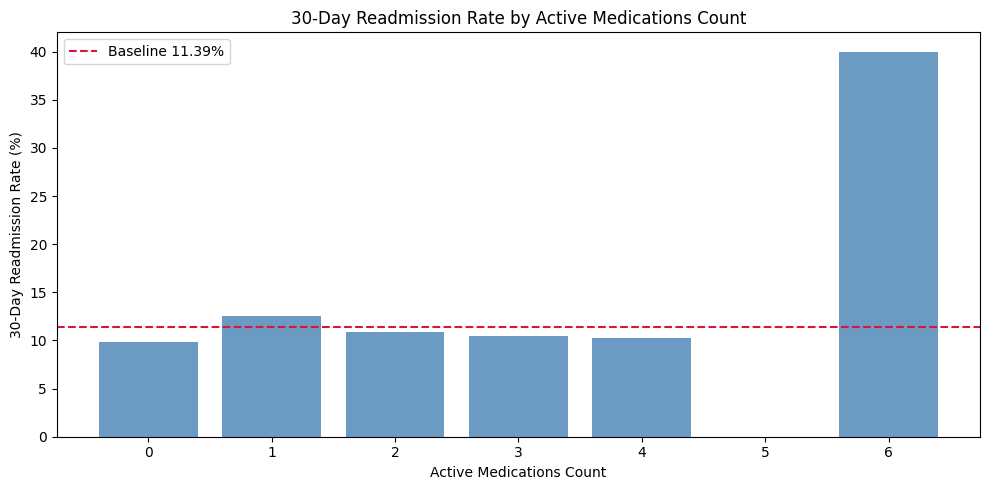

In [23]:
# Improved version — readmission RATE by active medication count
# More analytically useful than raw frequency

rate_by_active_meds = pd.read_sql("""
    SELECT
        num_active_medications,
        COUNT(*)                                                    AS encounters,
        SUM(led_to_30day_readmission)                               AS readmitted_30day,
        ROUND(SUM(led_to_30day_readmission) * 100.0
              / COUNT(*), 2)                                        AS readmission_rate_pct
    FROM public.vw_encounter_base
    GROUP BY num_active_medications
    ORDER BY num_active_medications
""", engine)

plt.figure(figsize=(10, 5))
plt.bar(
    rate_by_active_meds["num_active_medications"],
    rate_by_active_meds["readmission_rate_pct"],
    color="steelblue", alpha=0.8
)
plt.axhline(y=11.39, color="crimson", linestyle="--",
            label="Baseline 11.39%")
plt.xlabel("Active Medications Count")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Active Medications Count")
plt.legend()
plt.tight_layout()
save_path = output_dir / "05b_rate_by_active_meds.png"
plt.savefig(
    charts_dir / "05b_rate_by_active_meds.png", dpi=150, bbox_inches="tight"
)
plt.show()
plt.close()

### 10. Clinical Analysis — 30-Day Readmission Rate by Active Medication Count

**Analytical Question:**  
Does the specific count of active (targeted) medications scale with short-term readmission rates, and does it reveal a different trend than the raw frequency distribution?

---

#### Key Findings & Insights:
* **The "One-Medication" Peak:** For patients with 0 to 4 active medications, the readmission rate remains incredibly flat, hovering right around our baseline. 
  * The rate peaks slightly at **~12.5%** for patients with exactly **1 active medication** (just above the **11.39% baseline**). 
  * Interestingly, patients on 2, 3, or 4 active medications actually see their readmission rates dip slightly *below* the baseline.
* **The Extreme Outlier (6 Medications):** Patients with exactly **6 active medications** appear to have a massive 30-day readmission rate of **40%**. 
* **The Sample Size "Trap" (Statistical Warning):** 
  * As observed in the previous histogram, the vast majority of our database is concentrated at 0, 1, and 2 active medications. 
  * There are virtually no patients with 5 active medications (hence the gap in the chart), and likely only a handful of encounters with exactly 6 active medications. 
  * Consequently, the **40% spike at 6 medications is almost certainly a statistical anomaly** caused by a tiny sample size (low denominator) rather than a true clinical trend.

#### Takeaway for the Analysis Report:
Normalizing the data into rates instead of raw counts reveals that **active medication count does not have a progressive, linear relationship with readmission risk**. Aside from a small sample size artifact at 6 medications, a patient on 4 active medications is no more likely to be readmitted than a patient on 0. This stands in sharp contrast to **total medication count (polypharmacy)**, which has a strong, stepwise impact on readmission.